<a href="https://colab.research.google.com/github/taissa-arruda/prog_estat/blob/main/Resolu%C3%A7%C3%A3o_labs/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercício 1.1**

**Método 1 — via soma de Bernoullis (simulação direta)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def binomial_negativa_bernoulli(r, p):
    sucessos = 0
    tentativas = 0
    while sucessos < r:
        tentativas += 1
        if np.random.uniform() < p:
            sucessos += 1
    return tentativas

**Método 2 — via soma de Geométricas**

In [2]:
def geometrica_inversao(p):
    u = np.random.uniform()
    return np.ceil(np.log(1 - u) / np.log(1 - p))

def binomial_negativa_soma_geometricas(r, p):
    total = 0
    for _ in range(r):
        total += geometrica_inversao(p)
    return total

**Método 3 — Recursivo**

In [3]:
def binomial_negativa_recursiva(r, p):
    U = np.random.uniform()
    k = r
    pk = p ** r
    F = pk
    while U > F:
        pk = pk * (k / (k - r + 1)) * (1 - p)
        k += 1
        F += pk
    return k

**Exercício 1.2 - Gerando as amostras e comparando com o numpy**

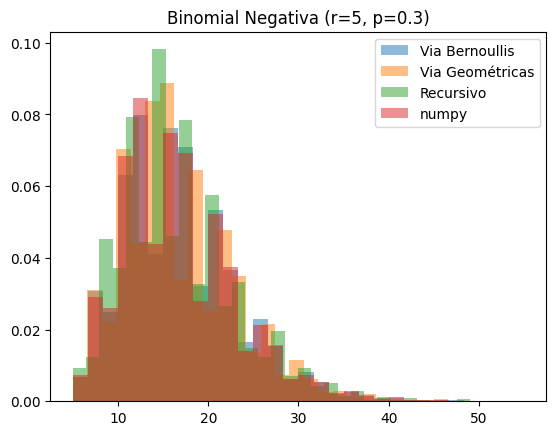

In [4]:
K = 5000
r = 5
p = 0.3

amostra_bernoulli = np.array([binomial_negativa_bernoulli(r, p) for _ in range(K)])
amostra_geometricas = np.array([binomial_negativa_soma_geometricas(r, p) for _ in range(K)])
amostra_recursiva = np.array([binomial_negativa_recursiva(r, p) for _ in range(K)])

# numpy conta só as FALHAS antes do r-ésimo sucesso, não o total de tentativas
amostra_numpy = np.random.negative_binomial(r, p, K) + r

plt.hist(amostra_bernoulli, bins=30, alpha=0.5, density=True, label='Via Bernoullis')
plt.hist(amostra_geometricas, bins=30, alpha=0.5, density=True, label='Via Geométricas')
plt.hist(amostra_recursiva, bins=30, alpha=0.5, density=True, label='Recursivo')
plt.hist(amostra_numpy, bins=30, alpha=0.5, density=True, label='numpy')
plt.legend()
plt.title(f'Binomial Negativa (r={r}, p={p})')
plt.show()

**Exercício 1.3 - Comparando o tempo dos três métodos**

In [5]:
tempos = {}
for nome, funcao in [('Bernoullis', binomial_negativa_bernoulli),
                      ('Geométricas', binomial_negativa_soma_geometricas),
                      ('Recursivo', binomial_negativa_recursiva)]:
    inicio = time.time()
    [funcao(r, p) for _ in range(K)]
    tempos[nome] = time.time() - inicio

for nome, tempo in tempos.items():
    print(f'{nome}: {tempo:.4f}s')

Bernoullis: 0.4490s
Geométricas: 0.3426s
Recursivo: 0.0521s


**Exercício 2**

**Versão 1 — Correta (troca entre i e o final do array)**

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def fisher_yates_correto(n, M, N):
    populacao = np.array([1]*N + [0]*M)  # 1 = sucesso, 0 = fracasso
    tamanho = M + N

    for i in range(n):
        j = np.random.randint(i, tamanho)  # sorteia entre i e o final
        populacao[i], populacao[j] = populacao[j], populacao[i]

    return np.sum(populacao[:n])

**Versão 2 — "Errada" (sempre sorteia entre 0 e o final, ignorando i)**

In [9]:
def fisher_yates_errado(n, M, N):
    populacao = np.array([1]*N + [0]*M)
    tamanho = M + N

    for i in range(n):
        j = np.random.randint(0, tamanho)  # sempre entre 0 e o final, não entre i e o final
        populacao[i], populacao[j] = populacao[j], populacao[i]

    return np.sum(populacao[:n])

**Gerando e comparando as amostras**

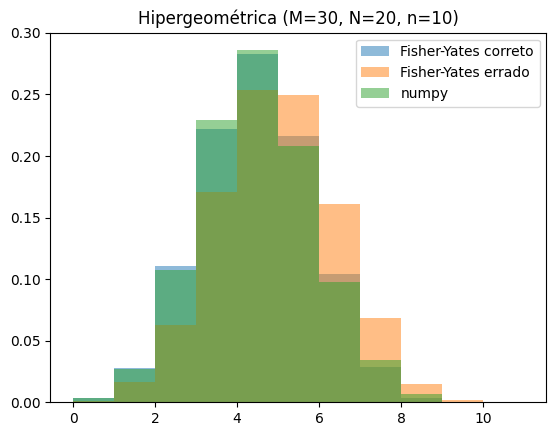

In [8]:
K = 5000
M, N, n = 30, 20, 10

amostra_correta = np.array([fisher_yates_correto(n, M, N) for _ in range(K)])
amostra_errada = np.array([fisher_yates_errado(n, M, N) for _ in range(K)])
amostra_numpy = np.random.hypergeometric(ngood=N, nbad=M, nsample=n, size=K)

plt.hist(amostra_correta, bins=range(n+2), alpha=0.5, density=True, label='Fisher-Yates correto')
plt.hist(amostra_errada, bins=range(n+2), alpha=0.5, density=True, label='Fisher-Yates errado')
plt.hist(amostra_numpy, bins=range(n+2), alpha=0.5, density=True, label='numpy')
plt.legend()
plt.title(f'Hipergeométrica (M={M}, N={N}, n={n})')
plt.show()

**Exercício 3**

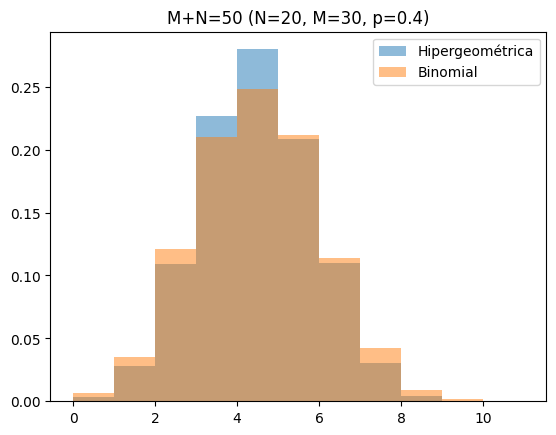

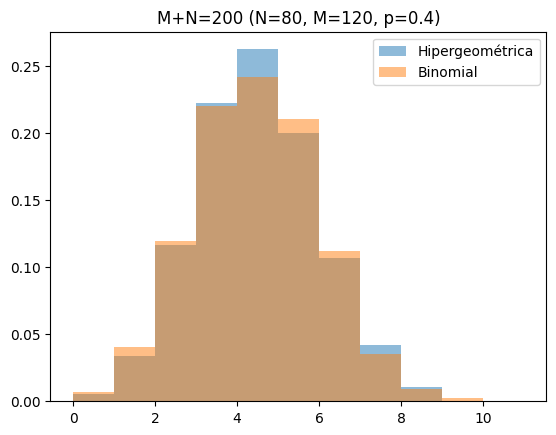

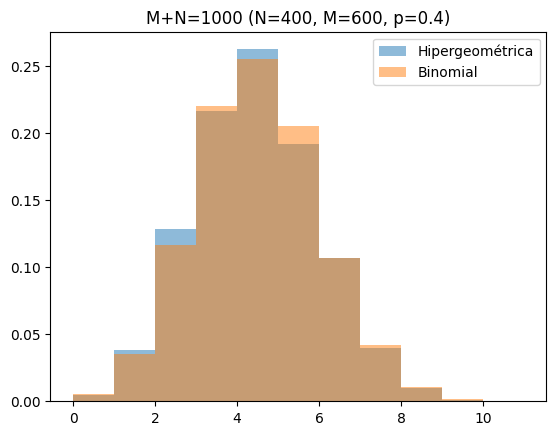

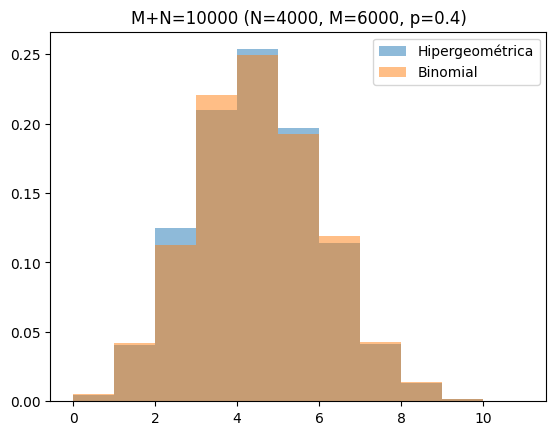

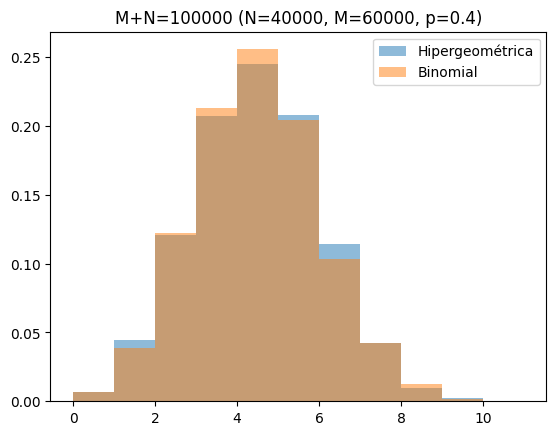

In [10]:
import numpy as np
import matplotlib.pyplot as plt

K = 5000
n = 10
p = 0.4  # proporção de sucessos que queremos manter fixa

totais = [50, 200, 1000, 10000, 100000]  # valores crescentes de M+N

for total in totais:
    N = int(total * p)        # sucessos na população
    M = total - N              # fracassos na população

    amostra_hiper = np.random.hypergeometric(ngood=N, nbad=M, nsample=n, size=K)
    amostra_binom = np.random.binomial(n=n, p=p, size=K)

    plt.hist(amostra_hiper, bins=range(n+2), alpha=0.5, density=True, label='Hipergeométrica')
    plt.hist(amostra_binom, bins=range(n+2), alpha=0.5, density=True, label='Binomial')
    plt.legend()
    plt.title(f'M+N={total} (N={N}, M={M}, p={p})')
    plt.show()

In [11]:
for total in totais:
    N = int(total * p)
    M = total - N

    var_binomial = n * p * (1 - p)
    var_hiper = n * p * (1 - p) * (M + N - n) / (M + N - 1)

    diferenca = abs(var_hiper - var_binomial)
    print(f'M+N={total}: Var(Binomial)={var_binomial:.4f}, Var(Hiper)={var_hiper:.4f}, diferença={diferenca:.6f}')

M+N=50: Var(Binomial)=2.4000, Var(Hiper)=1.9592, diferença=0.440816
M+N=200: Var(Binomial)=2.4000, Var(Hiper)=2.2915, diferença=0.108543
M+N=1000: Var(Binomial)=2.4000, Var(Hiper)=2.3784, diferença=0.021622
M+N=10000: Var(Binomial)=2.4000, Var(Hiper)=2.3978, diferença=0.002160
M+N=100000: Var(Binomial)=2.4000, Var(Hiper)=2.3998, diferença=0.000216
